# Graph internal PII

- **Human** message stays in `state.messages` (original email).
- Each LLM node **appends** an **AI** message (raw JSON string) for the trace.
- Structured results live in **`pii_email`** and **`todo_list`** on `GlobalState`.
- TODO extraction runs in an **isolated subgraph** (`TODOState`: only `text` in); a **bridge** node maps `pii_email.text` → subgraph → `todo_list` + `messages` on `GlobalState`. Build cells need no `reducer_session`; invoke only inside `with reducer_session(...)`. The bridge forwards LangGraph `config` (e.g. `thread_id`) into the subgraph — details in `src/llm_nodes/todo_list/graph.py`.
- Parent Mermaid shows one `todo_list_node` box; optional second plot for the subgraph alone (`todo_graph.get_graph()`).
- `BaseReducerReader` only **observes** and vaults message copies — it does not redact.

Re-run graph + invoke cells after edits.

In [1]:
import sys

# See README.md - only valid for devcontainer workflow!
sys.path.insert(0, "/workspace")

from typing import Callable

from src.reducer.base_reader import BaseReducerReader

from langgraph.graph import END, START, StateGraph
from langchain_core.messages import HumanMessage
import logging

from IPython.display import Image, display
from src.llm_nodes.global_state import GlobalState
from src.logging_setup import get_logger
from src.reducer.reducer_session import reducer_session
from src.llm_nodes.pii_email.nodes import get_pii_email_node
from src.llm_nodes.todo_extract.graph import build_todo_extract_subgraph, make_todo_extract_subgraph_runner
from src.llm_nodes.todo_markdown.graph import build_todo_markdown_subgraph, make_todo_markdown_subgraph_runner


Email, ...

In [2]:
# MODEL = "ollama_chat/llama3.2:3b"
MODEL = "groq/llama-3.3-70b-versatile"

pii_email = """
This is a confidental email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.
"""

# email_domain_valid = ["ourcompany.com"]

logger = get_logger(__name__, "assorted/session4/langgraph.ipynb")
logger.setLevel(logging.INFO)

In [3]:
# Isolated subgraph (TODOState) + bridge node for the parent graph
todo_extract_graph = build_todo_extract_subgraph(MODEL)
run_todo_extract_graph = make_todo_extract_subgraph_runner(todo_extract_graph)

toto_markdown_graph = build_todo_markdown_subgraph(MODEL)
run_todo_markdown_graph = make_todo_markdown_subgraph_runner(toto_markdown_graph)



Parent graph (GlobalState)

`todo_list_node` is the bridge (`run_todo_subgraph`), not the raw subgraph.

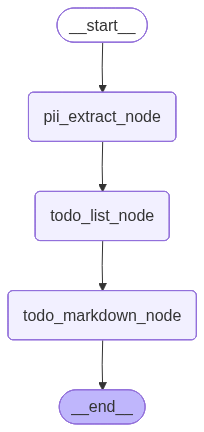

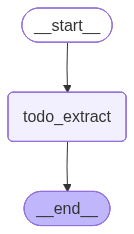

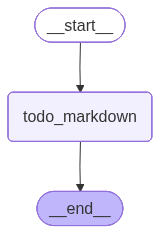

In [4]:
build_graph = StateGraph(GlobalState)

build_graph.add_node("pii_extract_node", get_pii_email_node(model=MODEL))
build_graph.add_node("todo_list_node", run_todo_extract_graph)
build_graph.add_node("todo_markdown_node", run_todo_markdown_graph)

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", "todo_markdown_node")
build_graph.add_edge("todo_markdown_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(todo_extract_graph.get_graph().draw_mermaid_png()))
display(Image(toto_markdown_graph.get_graph().draw_mermaid_png()))

Invoke

In [5]:
def make_reader(get_thread_id: Callable[[], str]):
    return BaseReducerReader(get_thread_id=get_thread_id)


reducer = None
with reducer_session("Chat-ABC", factory=make_reader) as session:


    reducer = session.reducer

    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(graph, state)

    state = GlobalState.model_validate(reply)
    logging.debug("Observed, raw messages with content:")
    for m in state.messages:
        if hasattr(m, "content") and isinstance(m.content, str):
            logger.debug(f"{m.type}: {m.content}")

    print("----")
    
    print("")
    print("Email extraction result:")
    print(f"\ttext: {state.pii_email.text}\n")
    print(f"\trecognized_emails: {state.pii_email.recognized_emails}")
    print(f"\traw_emails: {state.pii_email.raw_emails}")
    print(f"\tnormalized_emails: {state.pii_email.normalized_emails}")
   
    print("")
    print("TODO list:")
    for k, item in enumerate(state.todo_list.items):
        print(f"  {k + 1}): who={item.who}, what={item.what}, when={item.when}")


    print("")
    print("TODO markdown:")
    print(state.todo_markdown.markdown)

    final_todo = state.todo_markdown.markdown
    for k, email in enumerate(state.pii_email.normalized_emails):
        placeholder = f"EMAIL{k}"
        final_todo = final_todo.replace(placeholder, email)

    print("--- Final TODO ---")
    print(final_todo)

   


----

Email extraction result:
	text: This is a confidental email. Task EMAIL0 to buy a cup of coffee, EMAIL1 needs to plant a tree by tomorrow, and EMAIL2 needs to reach out to all employees regarding the current coffee shortage as it is demotivating our technical staff. Due date, if not said otherwise, is today.

	recognized_emails: ['ulf.wendel@ phpdoc dot de', 'ulf.wendel@phpdoc.de', 'cto@ourcompany.com']
	raw_emails: ['ulf.wendel@phpdoc.de', 'ulf.wendel@phpdoc.de', 'cto@ourcompany.com']
	normalized_emails: ['ulf.wendel@phpdoc.de', 'ulf.wendel@phpdoc.de', 'cto@ourcompany.com']

TODO list:
  1): who=EMAIL0, what=buy a cup of coffee, when=today
  2): who=EMAIL1, what=plant a tree, when=tomorrow
  3): who=EMAIL2, what=reach out to all employees regarding the current coffee shortage, when=today

TODO markdown:
# EMAIL0
- [ ] buy a cup of coffee (by today)

# EMAIL1
- [ ] plant a tree (by tomorrow)

# EMAIL2
- [ ] reach out to all employees regarding the current coffee shortage (by toda

Vault

In [6]:
vault = reducer.get_vault_for_thread("Chat-ABC")
for k, v in vault.get():
    logger.debug(f"{k}: {v}")

reducer.reset_all()